In [1]:
import torch 
import torch.nn as nn

In [2]:
class ResNetBlock(nn.Module):
    def __init__(self, channels: int):
        # Khởi tạo khối ResNet với channels: là số chiều của ảnh đầu vào
        super(ResNetBlock, self).__init__()
        self.channels = channels
        self.num_groups = 8
        # Khởi tạo cho khối thứ 1
        self.norm1 = nn.GroupNorm(num_groups=self.num_groups, num_channels=self.channels)
        self.act1 = nn.SiLU()

        self.conv1 = nn.Conv2d(in_channels=channels, out_channels=channels, kernel_size=3,
                               stride=1, padding=1)
        # Khởi tạo cho khối thứ 2
        self.norm2 = nn.GroupNorm(num_groups=self.num_groups, num_channels=self.channels)
        self.act2 = nn.SiLU()

        self.conv2 = nn.Conv2d(in_channels=channels, out_channels=channels, kernel_size=3, 
                               stride=1, padding=1)

        
    def forward(self, x):
        residual = x
        # Khối 1
        x = self.norm1(x)
        x = self.act1(x)
        x = self.conv1(x)
        # Khối 2
        x = self.norm2(x)
        x = self.act2(x)
        x = self.conv2(x)

        return x + residual

In [3]:
# Cài đặt Encoder
class Encoder(nn.Module):
    def __init__(self, latent_features: int):
        super(Encoder, self).__init__()
        self.latent_features = latent_features
        self.conv0 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.resnet1 = ResNetBlock(channels=32)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1)
        self.resnet2 = ResNetBlock(channels=64)

        self.conv4 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=2, padding=1)
        self.resnet3 = ResNetBlock(channels=128)

        self.conv6 = nn.Conv2d(in_channels=128, out_channels= self.latent_features * 2, kernel_size=3, stride=2, padding = 1)
        
    def forward(self, x):
        x0 = self.conv0(x)
        x1 = self.resnet1(x0)

        x2 = self.conv2(x1)
        x3 = self.resnet2(x2)

        x4 = self.conv4(x3)
        x5 = self.resnet3(x4)
        
        x6 = self.conv6(x5)
        # Sử dụng torch.chunk để chia đôi tensor.
        muy, log_var = torch.chunk(x6, chunks=2, dim= 1)
        # Giải thích: mu và log_var sẽ có shape là (B, latent_features, 32, 32)
        return muy, log_var

In [4]:
# Latent space and reparameterization trick
def reparameterization_trick(mu: torch.Tensor, log_var: torch.Tensor):
    # 1. Lấy độ lệch chuẩn
    stdev = torch.exp(0.5 * log_var)

    # 2. Lấy mẫu nhiễu epsilon từ phân phối chuẩn tắc N(0, 1)
    # Hàm torch.randn_like cực kỳ tiện lợi: nó tự động tạo ra một tensor chứa nhiễu
    # có cùng kích thước (shape), cùng kiểu dữ liệu (dtype) và 
    # nằm trên cùng thiết bị (CPU hay GPU) với tensor `mu`.
    epsilon = torch.randn_like(mu)

    z = mu + stdev * epsilon

    return z

In [5]:
# Decoder
class Decoder(nn.Module):
    def __init__(self, latent_features: int):
        super(Decoder, self).__init__()
        self.latent_features = latent_features
        self.sigmoid = nn.Sigmoid()

        self.conv0 = nn.ConvTranspose2d(in_channels=self.latent_features, out_channels=128, kernel_size=4, stride=2,
                                        padding=1)
        self.resnet1 = ResNetBlock(channels=128)

        self.conv2 = nn.ConvTranspose2d(in_channels=128, out_channels=64, kernel_size=4, stride=2,
                                        padding=1)
        self.resnet2 = ResNetBlock(channels=64)

        self.conv4 = nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=4, stride=2,
                                        padding=1)
        self.resnet3 = ResNetBlock(channels=32)

        self.conv6 = nn.Conv2d(in_channels=32, out_channels=1, kernel_size=3, stride=1, 
                                        padding=1)
        
        
    def forward(self, x):
        x0 = self.conv0(x)
        x1 = self.resnet1(x0)

        x2 = self.conv2(x1)
        x3 = self.resnet2(x2)

        x4 = self.conv4(x3)
        x5 = self.resnet3(x4)
        
        logits = self.conv6(x5) # Shape: (B, 3, 256, 256)
        output = self.sigmoid(logits) # Ép giá trị về [0, 1]

        return output

In [6]:
# VAE class
class VAE(nn.Module):
    def __init__(self, latent_features: int):
        super(VAE, self).__init__()
        # Khởi tạo encoder và decoder
        self.encoder = Encoder(latent_features=latent_features)
        self.decoder = Decoder(latent_features=latent_features)
    
    def forward(self, x):
        # Encoder
        mu, log_var = self.encoder(x)
        # Reparameterization trick
        z = reparameterization_trick(mu=mu, log_var=log_var)
        # Decoder
        output = self.decoder(z)
        return output, mu, log_var

In [7]:
import torch.nn.functional as F

In [8]:
import torch.nn.functional as F
# Hàm loss
def vae_loss_fn(model, batch, lambda_rec = 1.0, lambda_kl = 1.0):
    # Chạy model
    output, mu, log_var = model(batch)
    # Reconstruction loss: Mean Absolute Loss
    reconstruction_loss = F.l1_loss(output, batch)
    # KL Loss
    kl_loss = 0.5 * torch.sum(mu.pow(2) + log_var.exp() - log_var - 1, dim=(1, 2, 3))
    kl_loss = torch.mean(kl_loss) # Lấy trung bình trên toàn batch
    # Tổng hợp Loss
    total_loss = lambda_rec * reconstruction_loss + lambda_kl * kl_loss
    
    return total_loss

In [9]:
# Train_step
def train_step(optimizer, batch, model, lambda_rec, lambda_kl):
    x = batch['image']
    # Xóa đạo hàm
    optimizer.zero_grad()
    # Forward pass
    total_loss = vae_loss_fn(model=model, batch=x, lambda_rec=lambda_rec, lambda_kl=lambda_kl)

    # Tình đạo hàm
    total_loss.backward()
    # Cập nhật trọng số
    optimizer.step()

    return total_loss.item()

In [10]:
import torch.optim as optim
from tqdm import tqdm

In [11]:

# Vòng lặp huấn luyện
def run_training(model, data_loader, config, device):
    model.train()
    model.to(device)

    # Khởi tạo optimizer
    optimizer = optim.AdamW(model.parameters(), lr=config['learning_rate'])

    # Vòng lặp epoch
    for epoch_idx in range(config['num_epochs']):
        epoch_losses = []

        # tqdm để tạo thanh tiến trình 
        progess_bar = tqdm(enumerate(data_loader), total=len(data_loader), desc=f"Epoch {epoch_idx+1}/{config['num_epochs']}")

        # Vòng lặp batch
        for i, batch in progess_bar:
            x = batch['image'].to(device)
            # Xóa sạch đạo hàm
            optimizer.zero_grad()
            # Tính loss
            loss = vae_loss_fn(
                model=model,
                batch=x,
                lambda_rec=config['lambda_rec'],
                lambda_kl=config['lambda_kl']
            )
            # Backpropagation
            loss.backward()

            # Cập nhật trọng số
            optimizer.step()

            current_loss = loss.item()
            epoch_losses.append(current_loss)

            # Cập nhật thanh tiến trình
            progess_bar.set_postfix(loss=f"{current_loss:.4f}")
        
        # Tính trung bình loss sau mỗi epoch
        avg_epoch_loss = sum(epoch_losses) / len(epoch_losses)
        print(f"Epoch {epoch_idx+1} | Loss trung bình: {avg_epoch_loss:.4f}\n")


    print("Huấn luyện xong")
    return model


In [12]:
import yaml
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset

with open("config.yaml", "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

c:\Users\ADMIN\duong_env_py10\lib\site-packages\triton\knobs.py:212: UserWarning: Failed to find cuobjdump.exe
  warnings.warn(f"Failed to find {binary}")
c:\Users\ADMIN\duong_env_py10\lib\site-packages\triton\knobs.py:212: UserWarning: Failed to find nvdisasm.exe
  warnings.warn(f"Failed to find {binary}")


In [20]:
# Xây dựng Wrapper cho Dataset
class MNISTDataset(Dataset):
    def __init__(self, root="./data", train=True, download=False):
        # Đổi kích thước lên 32*32 và chuyển thành Tensor [0, 1]
        self.transform = transforms.Compose([
            transforms.Resize(32),
            transforms.ToTensor()
        ])
        self.dataset = datasets.MNIST(root=root, train=train, download=download, transform=self.transform)

    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, index):
        img, label = self.dataset[index]
        return {'image': img, 'label': label}

# Khởi tạo Dataset và Dataloader
train_dataset = MNISTDataset(train=True, download=False)
train_loader = DataLoader(train_dataset, batch_size=config['batch_size'])

In [14]:
# Khởi tạo device
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Device: ", device)

Device:  cuda


In [ ]:
# Model
model = VAE(latent_features=config['latent_features'])

# Huấn luyện
trained_model = run_training(
    model=model,
    data_loader=train_loader,
    config=config,
    device=device
)

Device:  cuda


Epoch 1/10: 100%|██████████| 469/469 [00:19<00:00, 24.15it/s, loss=0.1135]


Epoch 1 | Loss trung bình: 0.1332



Epoch 2/10: 100%|██████████| 469/469 [00:18<00:00, 24.82it/s, loss=0.1135]


Epoch 2 | Loss trung bình: 0.1309



...

Epoch 8 | Loss trung bình: 0.1309



Epoch 9/10: 100%|██████████| 469/469 [00:20<00:00, 23.38it/s, loss=6.6826]   


Epoch 9 | Loss trung bình: 13.0135



Epoch 10/10: 100%|██████████| 469/469 [00:19<00:00, 23.74it/s, loss=4.9387] 

Epoch 10 | Loss trung bình: 8.9222

Huấn luyện xong


Trực quan kiến trúc VAE và dữ liệu

In [13]:
model = VAE(latent_features=config['latent_features'])
# 1. In tổng quan kiến trúc (Các layer và tham số)
print("=== KIẾN TRÚC TỔNG QUAN CỦA VAE ===")
print(model)

=== KIẾN TRÚC TỔNG QUAN CỦA VAE ===
VAE(
  (encoder): Encoder(
    (conv0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (resnet1): ResNetBlock(
      (norm1): GroupNorm(8, 32, eps=1e-05, affine=True)
      (act1): SiLU()
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (norm2): GroupNorm(8, 32, eps=1e-05, affine=True)
      (act2): SiLU()
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (resnet2): ResNetBlock(
      (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
      (act1): SiLU()
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (norm2): GroupNorm(8, 64, eps=1e-05, affine=True)
      (act2): SiLU()
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (conv4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))


In [16]:
# 2. In sự thay đổi kích thước dữ liệu khi đi qua mô hình
print("\n=== KÍCH THƯỚC DỮ LIỆU QUA TỪNG BƯỚC ===")
model.to(device)
# Ảnh đầu vào: (batch = 1, 1 kênh màu, 32x32)
dummy_input = torch.randn(1, 1, 32, 32).to(device)

# Truyền qua encoder
mu, log_var = model.encoder(dummy_input)
print(f"Input shape: {dummy_input.shape}")
print(f"Output của Encoder (mu): {mu.shape}")
print(f"Output của Encoder (log_var): {log_var.shape}")

# Lấy mẫu z
z = reparameterization_trick(mu=mu, log_var=log_var)
print(f"Latent vector (z) shape: {z.shape}")

# Truyền qua Decoder
output = model.decoder(z)
print(f"Output của Decoder: {output.shape}")


=== KÍCH THƯỚC DỮ LIỆU QUA TỪNG BƯỚC ===
Input shape: torch.Size([1, 1, 32, 32])
Output của Encoder (mu): torch.Size([1, 4, 4, 4])
Output của Encoder (log_var): torch.Size([1, 4, 4, 4])
Latent vector (z) shape: torch.Size([1, 4, 4, 4])
Output của Decoder: torch.Size([1, 1, 32, 32])


In [ ]:
print("=== REPARAMETERIZATION TRICK ===")
stdev = torch.exp(0.5 * log_var)
epsilon = torch.randn_like(mu)
z_sample = mu + stdev*epsilon

print(f"1. Giá trị trung bình (muy): \n{mu[0, :5].detach().cpu().numpy()}")
print(f"2. Độ lệch chuẩn (stdev): \n{stdev[0, :5].detach().cpu().numpy()}")
print(f"3. Nhiễu epsilon (N(0,1)) sinh ra ngẫu nhiên: \n{epsilon[0, :5].detach().cpu().numpy()}")
print(f"4. Vector tiềm ẩn z (z = mu + stdev * epsilon): \n{z_sample[0, :5].detach().cpu().numpy()}")

=== REPARAMETERIZATION TRICK ===
1. Giá trị trung bình (muy) của 5 đặc trưng đầu: 
[[[-0.03676762  0.16133167  0.20822439  0.07543493]
  [-0.01277744  0.26495826 -0.14735447  0.38026574]
  [-0.06088825  0.00200482  0.10725268  0.4321996 ]
  [-0.14411803  0.13263752 -0.09541304  0.21246164]]

 [[ 0.08511914  0.39901695  0.02949359  0.1207175 ]
  [ 0.03459448 -0.24511546 -0.42348158 -0.21266434]
  [ 0.06986298  0.20731133 -0.30301532  0.10292588]
  [-0.04296042 -0.02486456  0.07141127 -0.10015857]]

 [[ 0.12498336 -0.30927277 -0.12672035  0.0437128 ]
  [-0.1969869  -0.26747692 -0.16577096  0.2848128 ]
  [-0.04345338 -0.16577207 -0.16367814 -0.00625042]
  [-0.06631828  0.21074376 -0.27093172  0.14850408]]

 [[ 0.14570263 -0.10641843  0.03126525  0.05886277]
  [ 0.0360513  -0.14699888 -0.06888338 -0.01736921]
  [ 0.12050696 -0.38763073  0.08618987 -0.07745348]
  [-0.03201692  0.11030403  0.04797855  0.10788952]]]
2. Độ lệch chuẩn (stdev) của 5 đặc trưng đầu: 
[[[0.99954873 1.0377182  0.909

In [18]:
print("\n=== CHI TIẾT HÀM LOSS ===")
# Giả lập tính loss với ảnh thật và ảnh được tái tạo
batch_fake = torch.randn(16, 1, 32, 32).to(device=device)
output, mu_out, log_var_out = model(batch_fake)

rec_loss = F.l1_loss(output, batch_fake)
kl_loss = 0.5 * torch.sum(mu_out*mu_out + log_var_out.exp() - log_var_out - 1, dim=(1, 2, 3))
kl_loss = torch.mean(kl_loss)

print(f"Reconstruction Loss (Lỗi tái tạo L1): {rec_loss.item():.4f}")
print(f"KL Divergence Loss (Độ lệch phân phối): {kl_loss.item():.4f}")
print(f"Total Loss (Tổng 2 loss): {(rec_loss + kl_loss).item():.4f}")


=== CHI TIẾT HÀM LOSS ===
Reconstruction Loss (Lỗi tái tạo L1): 0.9061
KL Divergence Loss (Độ lệch phân phối): 2.4584
Total Loss (Tổng 2 loss): 3.3645


Trực quan dữ liệu

=== HÌNH DẠNG DỮ LIỆU ĐẦU VÀO ===
Kích thước 1 batch: torch.Size([128, 1, 32, 32])
Giải thích: (Batch_size=128, Số_kênh_màu=1, Chiều_cao=32, Chiều_rộng=32)



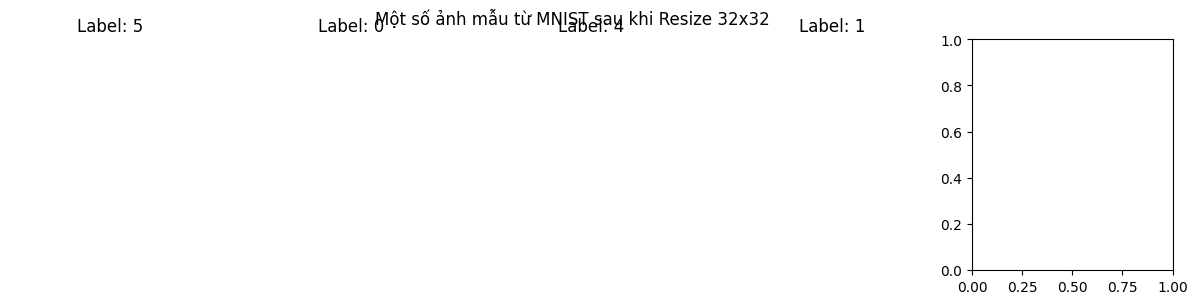

In [ ]:
import matplotlib.pyplot as plt

# lấy 1 batch dữ liệu đầu tiên
sample_batch = next(iter(train_loader))
images = sample_batch['image'].cpu()
labels = sample_batch['label'].cpu()

print("=== HÌNH DẠNG DỮ LIỆU ĐẦU VÀO ===")
print(f"Kích thước 1 batch: {images.shape}")
print("Giải thích: (Batch_size=128, Số_kênh_màu=1, Chiều_cao=32, Chiều_rộng=32)\n")

# Vẽ thử 4 ảnh đầu tiên trong batch
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(4):
    # images[i] có shape (1, 32, 32), cần squeeze() để về (32, 32) vẽ bằng matplotlib
    img_to_show = images[i].squeeze().numpy()
    # Vẽ ảnh
    axes[i].imshow(img_to_show, cmap='gray', vmin=0, vmax=1)
    axes[i].set_title(f"Label: {labels[i].item()}")
    axes[i].axis('off')

plt.suptitle("Một số ảnh mẫu từ MNIST sau khi Resize 32x32")

plt.tight_layout() # Tự động căn chỉnh khoảng cách
plt.show()
